Dataset shape: (43, 4)
             Section                  Metric  \
0  Executive summary         Investment view   
1   Company overview            Headquarters   
2   Company overview        Consumers served   
3  Business segments       Sempra California   
4  Business segments  Sempra Texas Utilities   

                                 Value  \
0  Watchlist / cautiously constructive   
1                San Diego, California   
2                    Nearly 40 million   
3                   SDG&E and SoCalGas   
4        Oncor and Sharyland Utilities   

                                             Comment  
0  Long-term utility-growth and income case; expo...  
1  North American energy infrastructure and regul...  
2             Company-reported broad customer reach.  
3  Regulated electric and gas networks; Californi...  
4  Electric transmission and distribution exposur...  
Best K: 7 | Silhouette: 0.105
Cluster 0: data, share data, market, share, reported, range, market data, p

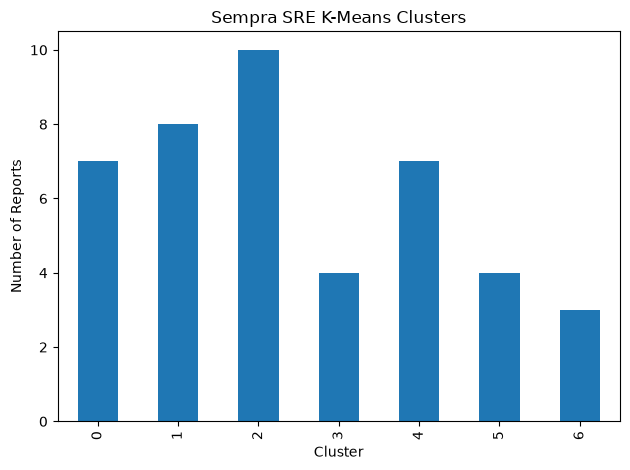

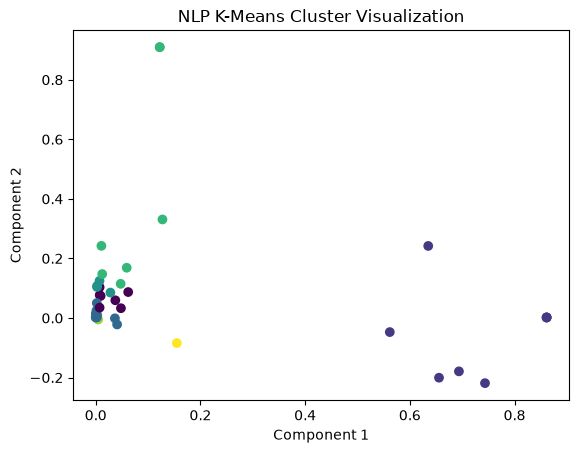

Saved: Sempra_SRE_NLP_KMeans_Results.csv


In [1]:

# Sempra SRE Report: NLP + K-Means

import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

# 1. Load dataset
df = pd.read_csv("Sempra_SRE_Full_Detailed_Report.csv")
print("Dataset shape:", df.shape)
print(df.head())

# 2. Select text columns and combine them
text_cols = df.select_dtypes(include=["object", "string"]).columns
if len(text_cols) == 0:
    raise ValueError("No text columns found.")

df["Text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 3. NLP text cleaning
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", " ", text.lower())
    return re.sub(r"\s+", " ", text).strip()

df["Clean_Text"] = df["Text"].apply(clean_text)
df = df[df["Clean_Text"] != ""].copy()

# 4. TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words="english", max_features=3000,
                        ngram_range=(1, 2), min_df=1)
X = tfidf.fit_transform(df["Clean_Text"])

# 5. Find best K using silhouette score
if X.shape[0] < 3:
    raise ValueError("At least 3 non-empty reports are needed.")

scores = {}
for k in range(2, min(8, X.shape[0])):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)
print("Best K:", best_k, "| Silhouette:", round(scores[best_k], 3))

# 6. Final K-Means clustering
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 7. Display keywords per cluster
terms = tfidf.get_feature_names_out()
for i, center in enumerate(model.cluster_centers_):
    top = center.argsort()[-10:][::-1]
    print(f"Cluster {i}:", ", ".join(terms[top]))

# 8. Plot cluster sizes
df["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Sempra SRE K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.show()

# 9. Optional 2D visualization
if X.shape[1] >= 2:
    coords = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)
    plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"], cmap="viridis")
    plt.title("NLP K-Means Cluster Visualization")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# 10. Save results
df.to_csv("Sempra_SRE_NLP_KMeans_Results.csv", index=False)
print("Saved: Sempra_SRE_NLP_KMeans_Results.csv")
